In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("CustomerChurn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
df.drop("customerID",axis=1,inplace=True)

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [12]:
df.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df = df.dropna(subset=['TotalCharges'])

In [14]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Churn Distribution

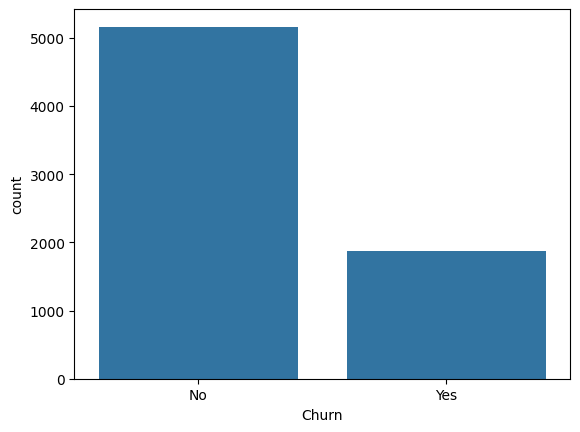

In [15]:
sns.countplot(x="Churn", data=df)
plt.show()

### Contract VS Churn

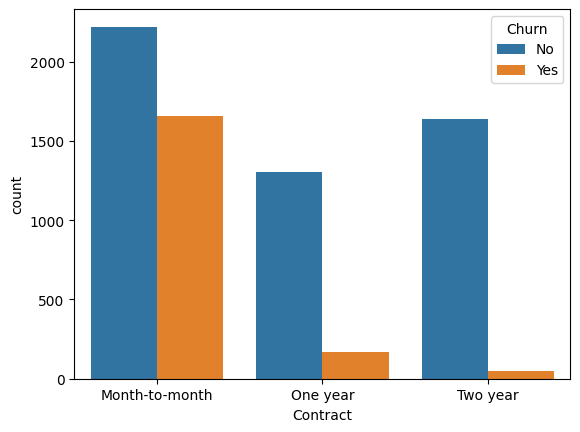

In [16]:
sns.countplot( x="Contract", hue="Churn",data=df)
plt.show()

### Internet Service vs Churn

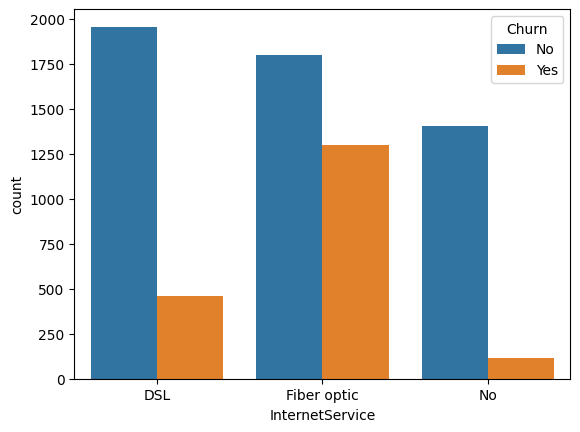

In [17]:
sns.countplot( x="InternetService",hue="Churn",data=df)
plt.show()

### Encoding

In [18]:
from sklearn.preprocessing import OrdinalEncoder

In [19]:
ord=OrdinalEncoder()
cal=df.select_dtypes(object).columns

In [20]:
cal

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [21]:
df[cal]=ord.fit_transform(df[cal])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,29.85,29.85,0.0
1,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0,56.95,1889.50,0.0
2,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,53.85,108.15,1.0
3,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,42.30,1840.75,0.0
4,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,70.70,151.65,1.0


In [22]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Feature And Response

In [23]:
x=df.iloc[:,: -1]
y=df.iloc[:,-1]

### Train & Test

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
xtrain, xtest, ytrain, ytest   = train_test_split(x, y, test_size=0.2, random_state=1)

### Model Selection

### KNN

In [26]:
from sklearn.neighbors import KNeighborsClassifier

In [27]:
knn = KNeighborsClassifier()
knn.fit(xtrain, ytrain)

knnyp = knn.predict(xtest)

In [28]:
knntrain = knn.score(xtrain, ytrain)
knntest  = knn.score(xtest, ytest)

print(knntrain, "   ", knntest)

0.8304     0.767590618336887


### Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
xtrain1, xtest1, ytrain1, ytest1   = train_test_split(x, y, test_size=0.2, random_state=1, stratify=y)

In [31]:
logreg = LogisticRegression()

logreg.fit(xtrain1, ytrain1)

logreg.yp  =  logreg.predict(xtest1)

In [32]:
logregtrain = logreg.score(xtrain1, ytrain1)
logregtest  = logreg.score(xtest1, ytest1)

print(logregtrain, "   ", logregtest)

0.7969777777777778     0.8031272210376688


### SVM

In [33]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [34]:
ss = StandardScaler()

xtrain = ss.fit_transform(xtrain)

xtest  = ss.transform(xtest)

In [35]:
svm= SVC()

svm.fit(xtrain, ytrain)

svmyp= svm.predict(xtest)

In [36]:
svmtrain = svm.score(xtrain, ytrain)
svmtest  = svm.score(xtest, ytest)

print( svmtrain, "   ", svmtest)

0.8204444444444444     0.7917555081734187


In [37]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score :", r2_score(ytest, svmyp))
print("MAE :", mean_absolute_error(ytest, svmyp))
print("MSE :", mean_squared_error(ytest, svmyp))
print("RMSE :", np.sqrt(mean_squared_error(ytest, svmyp)))

R2 Score : -0.0820065825735028
MAE : 0.2082444918265814
MSE : 0.2082444918265814
RMSE : 0.45633813321547145


### Predictions

In [38]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [50]:
gender = int(input("Gender (Male/Female): "))
SeniorCitizen = int(input("Senior Citizen (0/1): "))
Partner = int(input("Partner (Yes/No): "))
Dependents = int(input("Dependents (Yes/No): "))
tenure = int(input("Tenure: "))
PhoneService = int(input("Phone Service (Yes/No): "))
MultipleLines = int(input("Multiple Lines (Yes/No/No phone service): "))
InternetService = int(input("Internet Service (DSL/Fiber optic/No): "))
OnlineSecurity = int(input("Online Security (Yes/No/No internet service): "))
OnlineBackup = int(input("Online Backup (Yes/No/No internet service): "))
DeviceProtection = int(input("Device Protection (Yes/No/No internet service): "))
TechSupport = int(input("Tech Support (Yes/No/No internet service): "))
StreamingTV =int( input("Streaming TV (Yes/No/No internet service): "))
StreamingMovies =int( input("Streaming Movies (Yes/No/No internet service): "))
Contract = int(input("Contract (Month-to-month/One year/Two year): "))
PaperlessBilling = int(input("Paperless Billing (Yes/No): "))
PaymentMethod =int( input("Payment Method: "))
MonthlyCharges = float(input("Monthly Charges: "))
TotalCharges = float(input("Total Charges: "))

result = logreg.predict([[gender, SeniorCitizen, Partner, Dependents, tenure,
                          PhoneService, MultipleLines, InternetService, OnlineSecurity,OnlineBackup,
                          DeviceProtection, TechSupport, StreamingTV,StreamingMovies, Contract,
                          PaperlessBilling, PaymentMethod,MonthlyCharges, TotalCharges]])
if result[0] == 1:
    print("The customer is likely to churn.")
else:
    print("The customer is not likely to churn.")
print(result[0])

Gender (Male/Female):  1
Senior Citizen (0/1):  2
Partner (Yes/No):  2
Dependents (Yes/No):  1
Tenure:  1
Phone Service (Yes/No):  2
Multiple Lines (Yes/No/No phone service):  0
Internet Service (DSL/Fiber optic/No):  0
Online Security (Yes/No/No internet service):  0
Online Backup (Yes/No/No internet service):  2
Device Protection (Yes/No/No internet service):  1
Tech Support (Yes/No/No internet service):  3
Streaming TV (Yes/No/No internet service):  15
Streaming Movies (Yes/No/No internet service):  1
Contract (Month-to-month/One year/Two year):  2
Paperless Billing (Yes/No):  2
Payment Method:  2
Monthly Charges:  108.4
Total Charges:  53.53


The customer is not likely to churn.
0.0


In [46]:
import pickle

In [48]:
with open("trainedmodel.pkl",mode="wb") as file:
    pickle.dump(logreg, file)